# Perceptron Lab — Cats vs Dogs with TensorFlow

This notebook trains a **single-neuron perceptron** (one `Dense(1)` layer in Keras)
on real cat and dog photos, and shows why one neuron isn't enough for image
recognition — which is exactly why deeper networks (CNNs) exist.

### Which Kaggle dataset to use

Use **"Cats-vs-Dogs" (a.k.a. the Microsoft Cats and Dogs dataset)**:

> **Kaggle page:** `shaunthesheep/microsoft-catsvsdogs-dataset`
> https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset

Why this one specifically:
- It's a direct Kaggle mirror of the original Microsoft/Asirra 25,000-photo dataset
  (12,500 cats + 12,500 dogs) — the same one used in most cats-vs-dogs tutorials.
- **No competition sign-up needed.** The official competition version
  (`kaggle.com/c/dogs-vs-cats`) requires joining the competition and accepting
  rules before you can download; this dataset page doesn't.
- Folder layout is simple and predictable: `PetImages/Cat/*.jpg` and
  `PetImages/Dog/*.jpg` — exactly what the loading code below expects.

**Alternative if you want a pre-split train/test folder structure**
(`train/cats`, `train/dogs`, `test/cats`, `test/dogs`) instead of one big folder
per class: `salader/dogsvscats` on Kaggle works the same way with Keras'
`image_dataset_from_directory`.

### How to get the data into this notebook
- **On Kaggle:** click *Add Input* → search "Cats-vs-Dogs" (shaunthesheep) → Add.
  The files will appear under `/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/`.
- **On Colab / locally:** either
  1. Download via the Kaggle API: `kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset`, then unzip, **or**
  2. Just run the cell below — it downloads the same dataset directly from
     Microsoft's official mirror (no Kaggle account needed) so this notebook
     runs standalone.

In [2]:
# conda activate "E:\100 Days Of Python\Python by microinformatics\MLOPS-PROJECT\venv"
import zipfile
import io
import os
import random
import urllib.request

import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

## 1. Get the data

If you're on **Kaggle** with the dataset added, set `ZIP_PATH = None` and point
`DATA_DIR` at `/kaggle/input/microsoft-catsvsdogs-dataset/PetImages` instead —
see the commented-out line below.

Otherwise, this cell downloads the same dataset directly (one-time, ~800 MB).

## 2. Load a manageable subset

The full dataset has 25,000 photos. For a quick lecture demo we only need a
few thousand: this pulls **800 cats + 800 dogs for training** and
**200 cats + 200 dogs for testing**, resizing everything to 64×64 pixels and
normalizing pixel values to 0–1.

A handful of files in this dataset are corrupted (0-byte or unreadable) —
the `try/except` below just skips those.

In [3]:
ZIP_PATH = "catsdogs.zip"
ZIP_URL = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

# 1. Download the dataset
if not os.path.exists(ZIP_PATH):
    print("Downloading the Cats and Dogs dataset (~800 MB, one-time)...")
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    print("Download complete.")
else:
    print("Dataset already downloaded.")
EXTRACT_DIR = "PetImages"
# 2. Extract the dataset
if not os.path.exists(EXTRACT_DIR):
    print("Extracting files...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction complete. Images are in the 'PetImages' folder.")
else:
    print("Dataset already extracted.")

# --- If running on Kaggle with the dataset added via "Add Input" instead, use: ---
# DATA_DIR = "/kaggle/input/microsoft-catsvsdogs-dataset/PetImages"
# (and skip the zip-based loader below in favor of reading directly from DATA_DIR)

Download complete.
Extracting files...
Extraction complete. Images are in the 'PetImages' folder.


In [4]:
IMG_SIZE = 64
N_PER_CLASS_TRAIN = 800
N_PER_CLASS_TEST = 200


def load_images(zip_path, folder, n_needed, skip_names):
    z = zipfile.ZipFile(zip_path)
    names = [n for n in z.namelist() if n.startswith(folder) and n.endswith(".jpg")]
    random.shuffle(names)

    images, used_names = [], []
    for name in names:
        if name in skip_names:
            continue
        if len(images) >= n_needed:
            break
        try:
            raw = z.read(name)
            img = Image.open(io.BytesIO(raw)).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
            images.append(np.array(img, dtype=np.float32) / 255.0)
            used_names.append(name)
        except Exception:
            continue  # skip corrupt files
    return images, used_names


print("Loading photos...")
cat_train, cat_train_names = load_images(ZIP_PATH, "PetImages/Cat/", N_PER_CLASS_TRAIN, set())
dog_train, dog_train_names = load_images(ZIP_PATH, "PetImages/Dog/", N_PER_CLASS_TRAIN, set())
cat_test, _ = load_images(ZIP_PATH, "PetImages/Cat/", N_PER_CLASS_TEST, set(cat_train_names))
dog_test, _ = load_images(ZIP_PATH, "PetImages/Dog/", N_PER_CLASS_TEST, set(dog_train_names))

X_train = np.array(cat_train + dog_train)
y_train = np.array([0] * len(cat_train) + [1] * len(dog_train))  # 0 = cat, 1 = dog
X_test = np.array(cat_test + dog_test)
y_test = np.array([0] * len(cat_test) + [1] * len(dog_test))

# shuffle the training set (right now it's all cats, then all dogs)
idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]

print("Train:", X_train.shape, " Test:", X_test.shape)

Loading photos...
Train: (1600, 64, 64, 3)  Test: (400, 64, 64, 3)


## 3. Peek at a few photos

Quick sanity check before training — always look at your data.

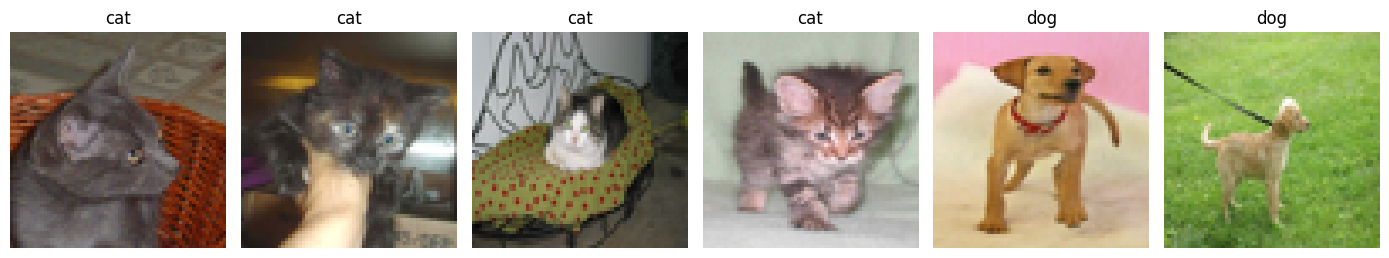

In [5]:
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
labels_map = {0: "cat", 1: "dog"}
for i, ax in enumerate(axes):
    ax.imshow(X_train[i])
    ax.set_title(labels_map[y_train[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Build the perceptron in TensorFlow/Keras

This is the whole point of the lab: a perceptron is just **one** `Dense` neuron.

- `Flatten()` turns each 64×64×3 photo into 12,288 raw pixel numbers.
- `Dense(1, activation="sigmoid")` **is** the perceptron — one weight per
  pixel, one bias, squashed to a 0–1 output by the sigmoid (a smooth version
  of the step function from the slides).

In [6]:
model = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Flatten(),
    keras.layers.Dense(1, activation="sigmoid"),   # <-- the perceptron itself
])

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

2026-09-03 16:37:13.771642: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train

`model.fit()` runs the predict → compare → adjust loop automatically, once per
epoch, for every training photo.

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/20
45/45 - 1s - 23ms/step - accuracy: 0.5139 - loss: 2.6174 - val_accuracy: 0.4938 - val_loss: 2.3369
Epoch 2/20
45/45 - 0s - 6ms/step - accuracy: 0.4924 - loss: 3.0721 - val_accuracy: 0.5063 - val_loss: 1.7312
Epoch 3/20
45/45 - 0s - 7ms/step - accuracy: 0.5167 - loss: 2.7171 - val_accuracy: 0.5688 - val_loss: 1.2202
Epoch 4/20
45/45 - 0s - 6ms/step - accuracy: 0.5146 - loss: 2.5438 - val_accuracy: 0.5437 - val_loss: 2.1809
Epoch 5/20
45/45 - 0s - 6ms/step - accuracy: 0.5264 - loss: 2.4711 - val_accuracy: 0.4938 - val_loss: 3.6288
Epoch 6/20
45/45 - 0s - 6ms/step - accuracy: 0.5611 - loss: 2.1133 - val_accuracy: 0.5063 - val_loss: 2.6790
Epoch 7/20
45/45 - 0s - 6ms/step - accuracy: 0.5153 - loss: 2.5113 - val_accuracy: 0.4938 - val_loss: 4.9256
Epoch 8/20
45/45 - 0s - 5ms/step - accuracy: 0.5417 - loss: 2.2728 - val_accuracy: 0.5562 - val_loss: 1.4353
Epoch 9/20
45/45 - 0s - 5ms/step - accuracy: 0.5479 - loss: 2.2479 - val_accuracy: 0.5625 - val_loss: 0.9950
Epoch 10/20
45/45 

Epoch 4/20


45/45 - 0s - 3ms/step - accuracy: 0.5153 - loss: 2.5421 - val_accuracy: 0.5000 - val_loss: 3.1879


Epoch 5/20


45/45 - 0s - 3ms/step - accuracy: 0.5597 - loss: 1.9269 - val_accuracy: 0.5688 - val_loss: 1.2079


...

45/45 - 0s - 3ms/step - accuracy: 0.5840 - loss: 1.8176 - val_accuracy: 0.5188 - val_loss: 1.2563


Epoch 19/20


45/45 - 0s - 3ms/step - accuracy: 0.5514 - loss: 2.2014 - val_accuracy: 0.6000 - val_loss: 1.3115


Epoch 20/20


45/45 - 0s - 3ms/step - accuracy: 0.5632 - loss: 2.0813 - val_accuracy: 0.5437 - val_loss: 1.3832


## 6. Evaluate on unseen test photos, and predict a few by hand

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Final test accuracy: {test_acc * 100:.1f}%  (test loss: {test_loss:.3f})")

preds = model.predict(X_test[:8], verbose=0)
print("\nSample predictions on unseen test photos:")
for i in range(8):
    predicted_label = labels_map[int(preds[i][0] >= 0.5)]
    true_label = labels_map[y_test[i]]
    print(f"  Photo {i+1}: predicted={predicted_label:4s} (confidence {preds[i][0]:.2f})  actual={true_label}")

Final test accuracy: 56.7%  (test loss: 1.439)

Sample predictions on unseen test photos:
  Photo 1: predicted=cat  (confidence 0.05)  actual=cat
  Photo 2: predicted=cat  (confidence 0.04)  actual=cat
  Photo 3: predicted=dog  (confidence 0.94)  actual=cat
  Photo 4: predicted=dog  (confidence 0.98)  actual=cat
  Photo 5: predicted=dog  (confidence 0.98)  actual=cat
  Photo 6: predicted=dog  (confidence 0.93)  actual=cat
  Photo 7: predicted=dog  (confidence 0.88)  actual=cat
  Photo 8: predicted=dog  (confidence 1.00)  actual=cat


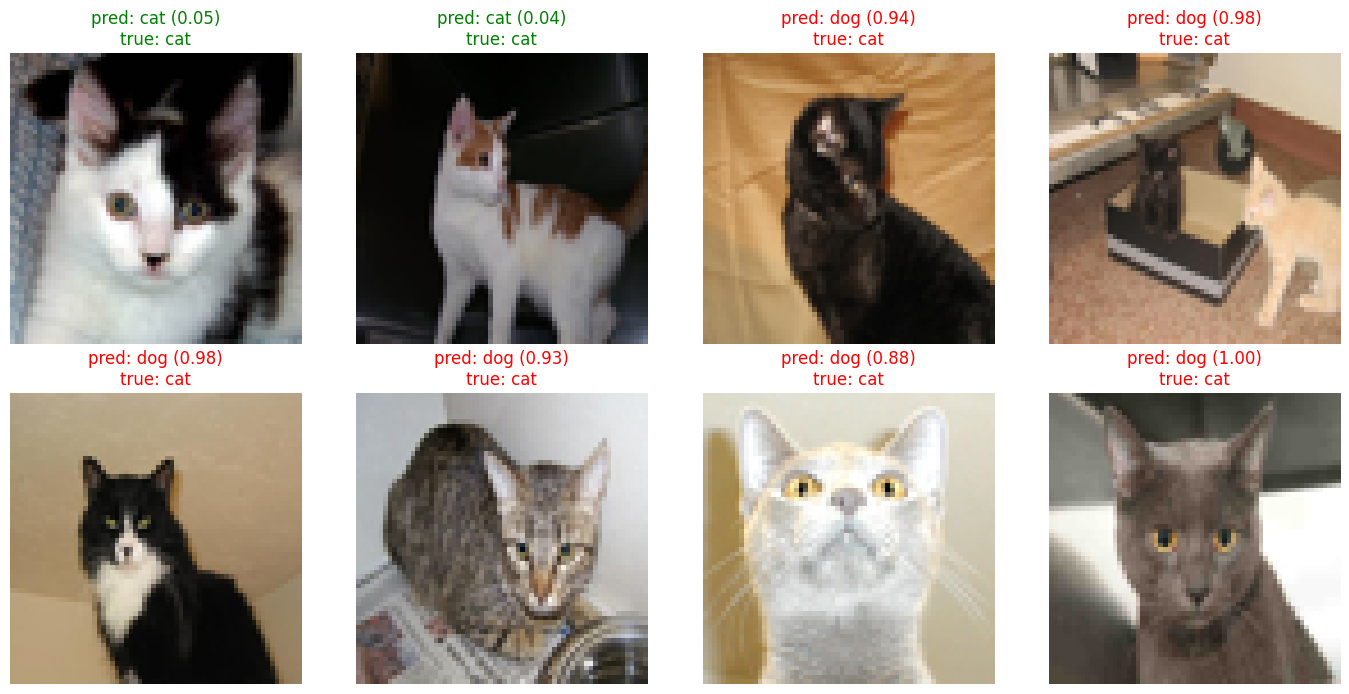

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i])
    predicted_label = labels_map[int(preds[i][0] >= 0.5)]
    true_label = labels_map[y_test[i]]
    correct = predicted_label == true_label
    ax.set_title(f"pred: {predicted_label} ({preds[i][0]:.2f})\ntrue: {true_label}",
                 color="green" if correct else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Why the accuracy is low — and what it teaches us

When we ran this lab, the perceptron landed around **50–55% test accuracy** —
barely better than flipping a coin.

That's expected, not a bug:

- A single perceptron only ever draws **one straight line (hyperplane)**
  through a 12,288-dimensional pixel space.
- Cat and dog photos aren't separable that way — a cat can be light or dark,
  facing left or right, close-up or far away. Raw pixel brightness has no
  notion of "ears," "fur texture," or "shape."
- This is the practical, real-data version of the **linear separability
  limit** from the lecture slides: the perceptron can't solve tasks that
  aren't separable by a straight line.

**The fix:** stack many neurons into layers, add non-linear activations
between them, and use convolutional layers that understand spatial patterns
(edges, textures, shapes) — that's a **Convolutional Neural Network (CNN)**,
and it's the natural next lecture after this one.